**The Core Loop Architecture**
- **Objective:** Write the standard boilerplate PyTorch training loop.
- **Task:** Train a standard torch.nn model.
- **Action:**
- 1. Define a simple model, nn.MSELoss(), and optim.Adam().
- 2. Write a loop iterating over epochs and the DataLoader.
- 3. Implement the core 5 steps inside the loop strictly in this order:
- 3.1. optimizer.zero_grad()
- 3.2. predictions = model(inputs) (Forward pass)
- 3.3. loss = criterion(predictions, targets) (Calculate loss)
- 3.4. loss.backward() (Backpropagation)
- 3.5. optimizer.step() (Update weights)
Plot the loss curve over time using Matplotlib.

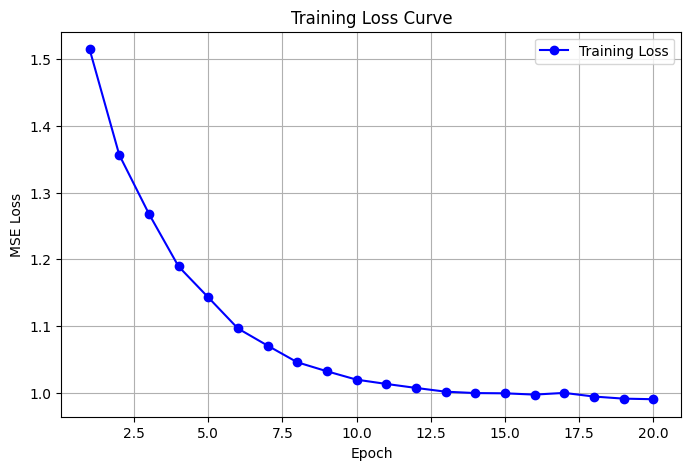

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# 1. Setup dummy data, model, loss function, and optimizer
torch.manual_seed(42)

# Create 100 samples of synthetic regression data (10 features)
X = torch.randn(100, 10)
y = torch.randn(100, 1)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Simple linear model
model = nn.Linear(10, 1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Variables to track loss history
epochs = 20
loss_history = []

# 2. Training Loop
for epoch in range(epochs):
    epoch_loss = 0.0
    for inputs, targets in dataloader:
        # 3.1. Clear gradients
        optimizer.zero_grad()
        
        # 3.2. Forward pass
        predictions = model(inputs)
        
        # 3.3. Calculate loss
        loss = criterion(predictions, targets)
        
        # 3.4. Backpropagation
        loss.backward()
        
        # 3.5. Update weights
        optimizer.step()
        
        epoch_loss += loss.item() * inputs.size(0)
        
    # Calculate average loss for the epoch
    epoch_loss /= len(dataloader.dataset)
    loss_history.append(epoch_loss)

# 4. Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='b', label='Training Loss')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.legend()
plt.show()

**Validation, Metrics, and Schedulers**
- **Objective:** Build a robust loop mimicking real-world experiment scripts.
- **Task:** Expand the beginner loop to prevent overfitting and adapt learning rates.
- **Action:**
- 1. Split your loop into two distinct phases per epoch: model.train() and model.eval().
- 2. In the eval phase, use with torch.no_grad(): to disable gradient tracking (saving memory/compute) and calculate validation accuracy/loss.
- 3. Integrate a learning rate scheduler (torch.optim.lr_scheduler.StepLR or ReduceLROnPlateau).
- 4. Implement Early Stopping: logic to break the loop if the validation loss hasn't improved for N consecutive epochs.

Epoch 01/50 | Train Loss: 0.6958 | Val Loss: 0.6660 | Val Acc: 62.0% | LR: 0.1000
Epoch 02/50 | Train Loss: 0.6809 | Val Loss: 0.6778 | Val Acc: 56.0% | LR: 0.1000
Epoch 03/50 | Train Loss: 0.6642 | Val Loss: 0.7357 | Val Acc: 58.0% | LR: 0.1000
Epoch 04/50 | Train Loss: 0.6589 | Val Loss: 0.7273 | Val Acc: 52.0% | LR: 0.1000
Epoch 05/50 | Train Loss: 0.6304 | Val Loss: 0.7477 | Val Acc: 52.0% | LR: 0.0500
Epoch 06/50 | Train Loss: 0.6228 | Val Loss: 0.7842 | Val Acc: 50.0% | LR: 0.0500

[Early Stopping Triggered] Validation loss did not improve for 5 consecutive epochs. Stopping training.


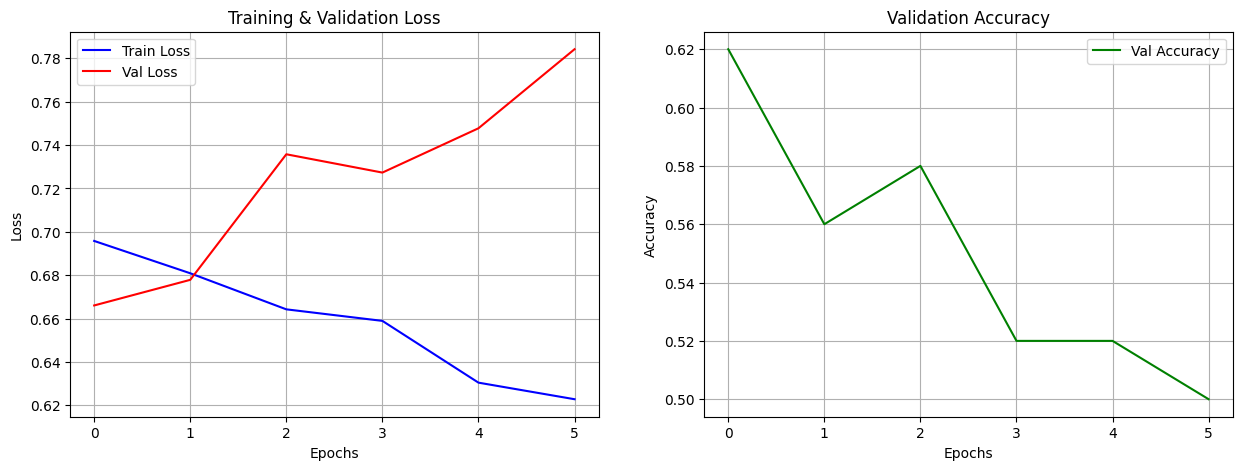

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# 1. Setup reproducibility, synthetic data, model, and loss
torch.manual_seed(42)

# Generate synthetic binary classification data
X_train = torch.randn(200, 10)
y_train = torch.randint(0, 2, (200, 1)).float()
X_val = torch.randn(50, 10)
y_val = torch.randint(0, 2, (50, 1)).float()

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

# Simple classification model
model = nn.Sequential(
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Linear(5, 1) # Output raw logits for BCEWithLogitsLoss
)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# Learning Rate Scheduler (decays LR by factor of 0.5 if val_loss doesn't improve for 2 epochs)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Early Stopping parameters
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# History tracking
train_losses = []
val_losses = []
val_accuracies = []

epochs = 50

# 2. Robust Training and Validation Loop
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        predictions = model(inputs)
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            predictions = model(inputs)
            loss = criterion(predictions, targets)
            
            running_val_loss += loss.item() * inputs.size(0)
            
            # Calculate classification accuracy
            probs = torch.sigmoid(predictions)
            preds = (probs >= 0.5).float()
            correct_predictions += (preds == targets).sum().item()
            total_samples += targets.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_predictions / total_samples
    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc*100:.1f}% | "
          f"LR: {optimizer.param_groups[0]['lr']:.4f}")
    
    # --- SCHEDULER & EARLY STOPPING LOGIC ---
    scheduler.step(epoch_val_loss)
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Optional: Save best model weights here via torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n[Early Stopping Triggered] Validation loss did not improve for {patience} consecutive epochs. Stopping training.")
            break

# 3. Plotting Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss Curve
ax1.plot(train_losses, label='Train Loss', color='b')
ax1.plot(val_losses, label='Val Loss', color='r')
ax1.set_title('Training & Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy Curve
ax2.plot(val_accuracies, label='Val Accuracy', color='g')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.show()